# Radiation, sea ice, and climate indices

`RESTOM` is the net top-of-atmosphere flux (`FSNT - FLNT`) and is the standard
equilibrium check. `ICEFRAC` converts sea-ice fraction into an area. `DP` is the
pressure thickness of each hybrid layer, built from the hybrid coefficients.
`NINO3.4` is registered under a dotted name, which is why the decorator takes an
explicit `name=`. It resolves like any other variable.

In [1]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import nc_time_axis  # registers the cftime axis converter for matplotlib
import x4c

x4c.set_style('journal')

# after set_style: it resets rcParams from matplotlibrc defaults, which includes the
# backend, so assert the inline backend last or figures are never captured
%matplotlib inline

# The tutorial runs against a reduced copy of a real CESM case. It is published as a
# GitHub Release asset rather than committed, so the first call downloads it into
# ~/.cache/x4c (override with $X4C_CACHE_DIR) and later calls reuse it. Set
# $X4C_SAMPLE_DIR to point at a copy you already have.
case_dir = x4c.fetch_sample_data(case='cesm1', verbose=False)
casename = os.path.basename(case_dir)
print('x4c', x4c.__version__)

x4c 2026.6.11


In [2]:
from x4c import diags

case = x4c.Timeseries(case_dir, grid_dict={'atm': 'ne16np4', 'ocn': 'g16'},
                      cesm_ver=1)

>>> case.root_dir: /glade/u/home/fengzhu/.cache/x4c/sample_data/cesm1_sample_data/b.e13.B1850C5.ne16_g16.icesm131_d18O_fixer.Miocene.3xCO2.005
>>> case.path_pattern: comp/proc/tseries/*/casename.hstr.vn.timespan.nc
>>> case.grid_dict: {'atm': 'ne16np4', 'ocn': 'g16', 'lnd': 'ne16np4', 'rof': 'ne16np4', 'ice': 'g16'}
>>> case.casename: b.e13.B1850C5.ne16_g16.icesm131_d18O_fixer.Miocene.3xCO2.005
>>> case.paths["atm"]["cam.h0"] created
>>> case.paths["ocn"]["pop.h"] created
>>> case.paths["lnd"]["clm2.h0"] created
>>> case.paths["ice"]["cice.h"] created
>>> case.vns["atm"]["cam.h0"] created
>>> case.vns["ocn"]["pop.h"] created
>>> case.vns["lnd"]["clm2.h0"] created
>>> case.vns["ice"]["cice.h"] created


In [3]:
for vn, span in [('RESTOM', (1, 10)), ('ICEFRAC', (1, 10)), ('DP', (1, 10))]:
    case.load(vn, timespan=span, verbose=False)
    da = case.ds[vn]
    print(f'  {vn:8s} {str(dict(da.sizes)):48s} {da.attrs.get("units")}')

  RESTOM   {'time': 120, 'ncol': 13826}                     W/m$^2$
  ICEFRAC  {'time': 120, 'nj': 384, 'ni': 320}              10$^6$ km$^2$
  DP       {'lev': 30, 'time': 120, 'ncol': 13826}          Pa


>>> Timespan: [0001-01-01 00:00:00, 0010-12-01 00:00:00]


>>> Timespan: [0001-01-01 00:00:00, 0010-12-01 00:00:00]


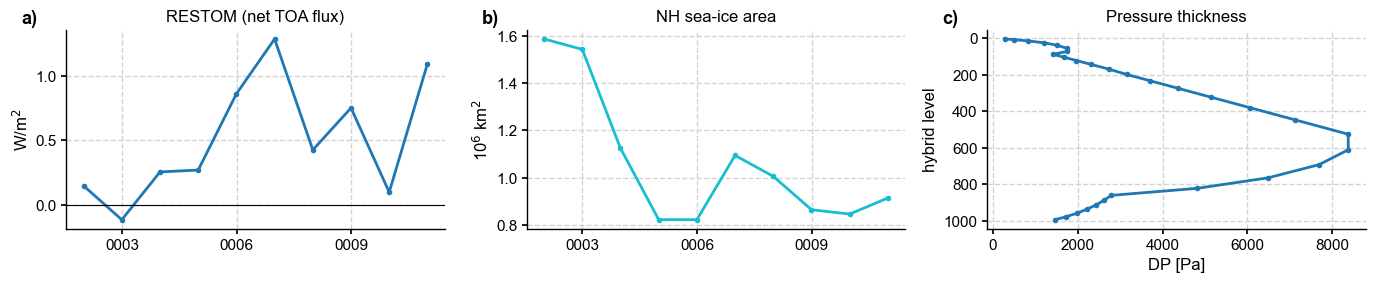

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3))

restom = case.calc('RESTOM:ann:gm', timespan=(1, 10), verbose=False)
axes[0].plot(restom.time, restom, marker='o', ms=3)
axes[0].axhline(0, color='k', lw=0.8)
axes[0].set(title='RESTOM (net TOA flux)', ylabel=restom.attrs.get('units'))

ice = case.calc('ICEFRAC:ann:nhs', timespan=(1, 10), verbose=False)
axes[1].plot(ice.time, ice, marker='o', ms=3, color='tab:cyan')
axes[1].set(title='NH sea-ice area', ylabel=ice.attrs.get('units'))

dp = case.ds['DP'].x.da.isel(time=0).x.gm if 'gw' in case.ds['DP'].x.da.attrs \
    else case.ds['DP'].x.da.isel(time=0).mean('ncol')
axes[2].plot(dp.values, dp['lev'].values, marker='.')
axes[2].invert_yaxis()
axes[2].set(title='Pressure thickness', xlabel='DP [Pa]', ylabel='hybrid level')

x4c.add_annotation(list(axes), style=')', loc_x=-0.12, fs=13)
fig.tight_layout()
x4c.showfig(fig)

## Climate indices

In [5]:
case.load('NINO3.4', timespan=(1, 1), verbose=False)
nino = case.ds['NINO3.4']
print('NINO3.4:', dict(nino.sizes), '|', nino.attrs.get('units'))
print(np.round(nino.values, 3))

NINO3.4: {'time': 12} | °C


[34.712 34.133 33.067 32.375 32.397 32.087 31.654 30.519 29.928 30.413
 30.818 31.103]


Note the units are `°C`, not `K`. That matters: `Timeseries.calc` subtracts 273.15
from anything labelled `K`, which would silently offset an index by that amount. When
you add your own diagnostic, label differences, anomalies and indices with their real
units — see [Adding a derived variable](diags-new_vars.ipynb).